# Khám phá xử lý dữ liệu

## 0. Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython import get_ipython

# Enable inline plotting in the notebook
get_ipython().run_line_magic('matplotlib', 'inline')

# Set style cho seaborn
sns.set_theme(style="whitegrid")


## 1. Khám phá tổng quan

### Đọc dữ liệu

In [3]:
# Load data
df_train = pd.read_csv('D:/ai_pratice_prj/Team9_ML_edu/House Price/data/txt/train.csv')
df_test = pd.read_csv('D:/ai_pratice_prj/Team9_ML_edu/House Price/data/txt/test.csv')


### Nội dung dữ liệu

In [3]:
display(df_train.head())
display(df_test.tail())


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [4]:
display(df_train.describe())


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
display(df_train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

## 2. Phân tích theo thuộc tính

### Phân tích biến mục tiêu

<Figure size 800x400 with 0 Axes>

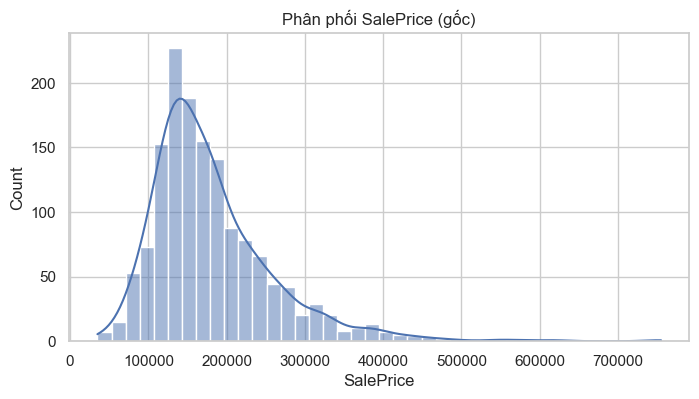

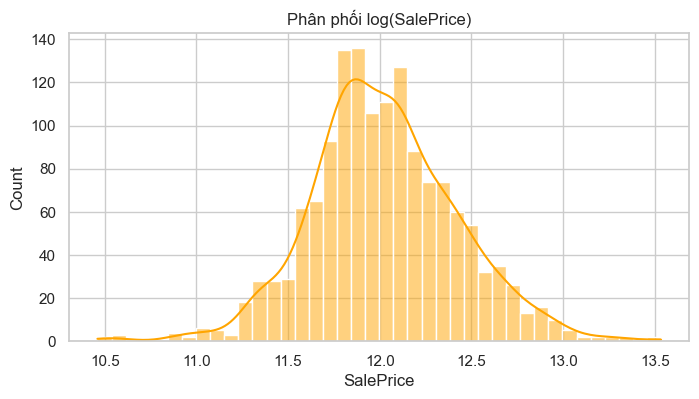

(1.8828757597682129, 0.12134661989685333)

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df_train['SalePrice'], kde=True, bins=40)
plt.title("Phân phối SalePrice (gốc)")
plt.show()

# Log-transform
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df_train['SalePrice']), kde=True, bins=40, color='orange')
plt.title("Phân phối log(SalePrice)")
plt.show()

# Kiểm tra skewness
df_train['SalePrice'].skew(), np.log1p(df_train['SalePrice']).skew()


### Phân phối dữ liệu theo biến phân loại

<Figure size 600x400 with 0 Axes>

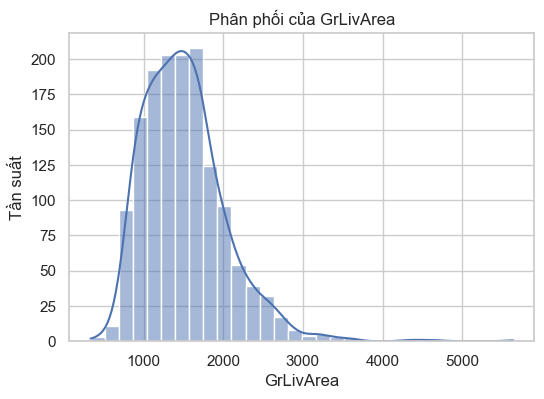

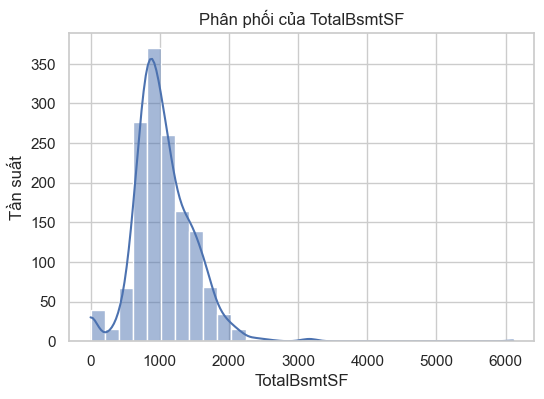

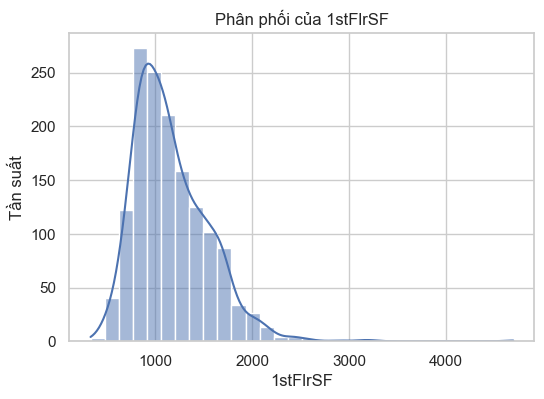

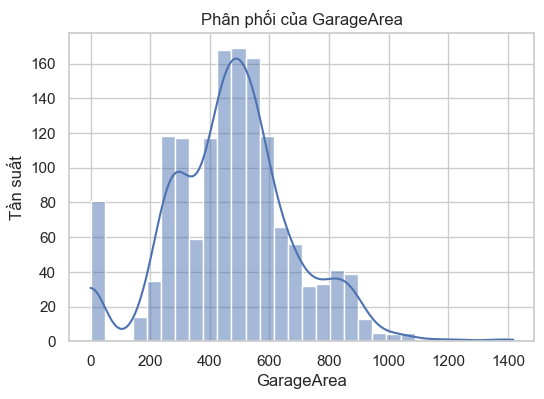

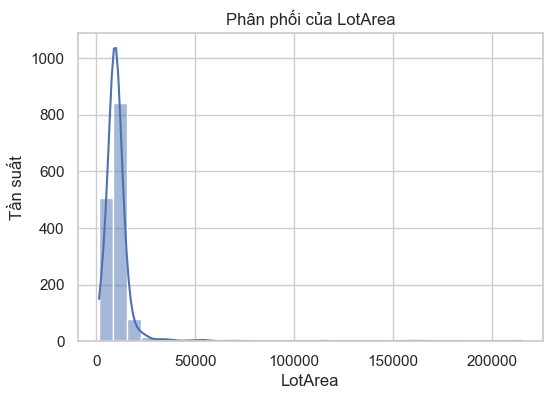

In [17]:
num_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotArea']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df_train[col].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.show()


### Phân phối theo biến định lượng

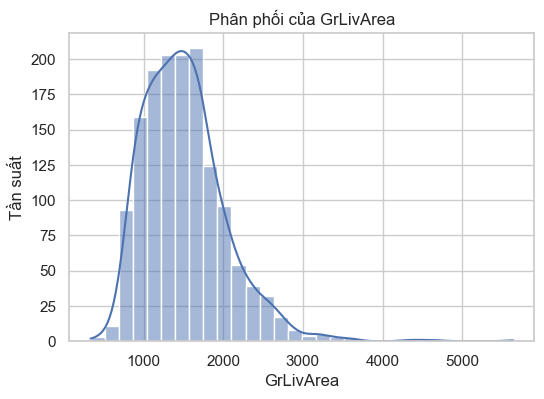

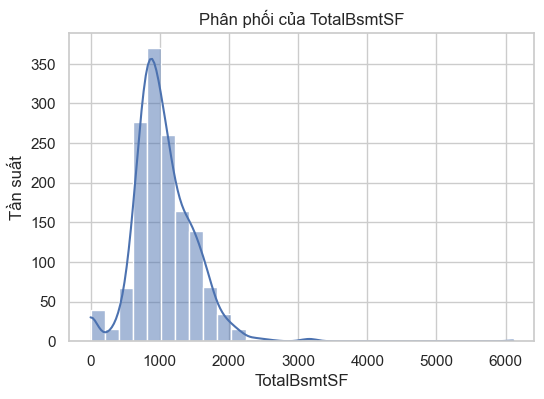

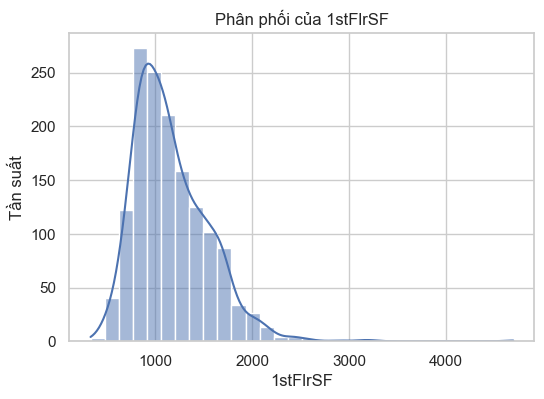

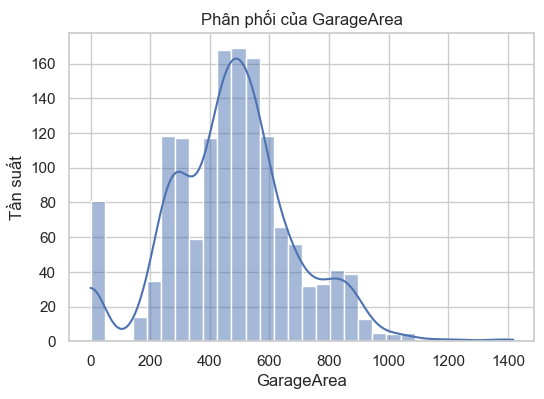

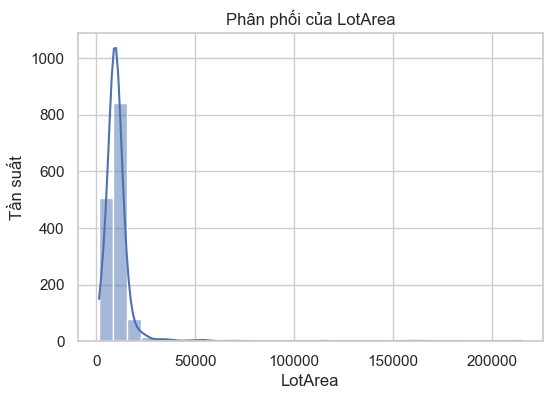

In [ ]:
num_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotArea']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df_train[col].dropna(), kde=True, bins=30)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.show()


### Phân tích dữ liệu thiếu 

,MissingCount,MissingPct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


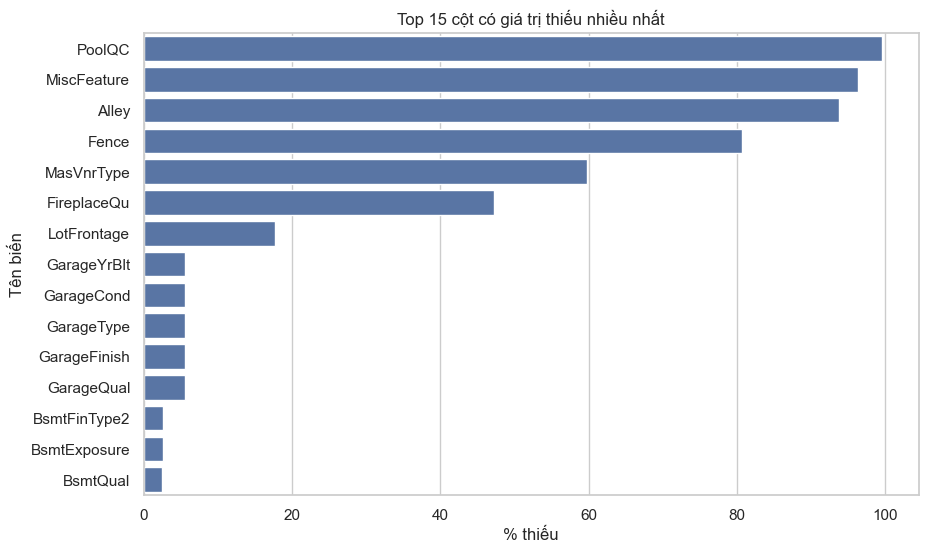

In [14]:
missing = df_train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df_train) * 100).round(2)
missing_table = pd.DataFrame({'MissingCount': missing, 'MissingPct': missing_pct})
missing_table.head(15)
display(missing_table)

# Biểu đồ top 15 cột có missing nhiều nhất
plt.figure(figsize=(10,6))
sns.barplot(x=missing_pct.head(15), y=missing_pct.head(15).index)
plt.title("Top 15 cột có giá trị thiếu nhiều nhất")
plt.xlabel("% thiếu")
plt.ylabel("Tên biến")
plt.show()


## 3. Phân tích tương quan và so sánh

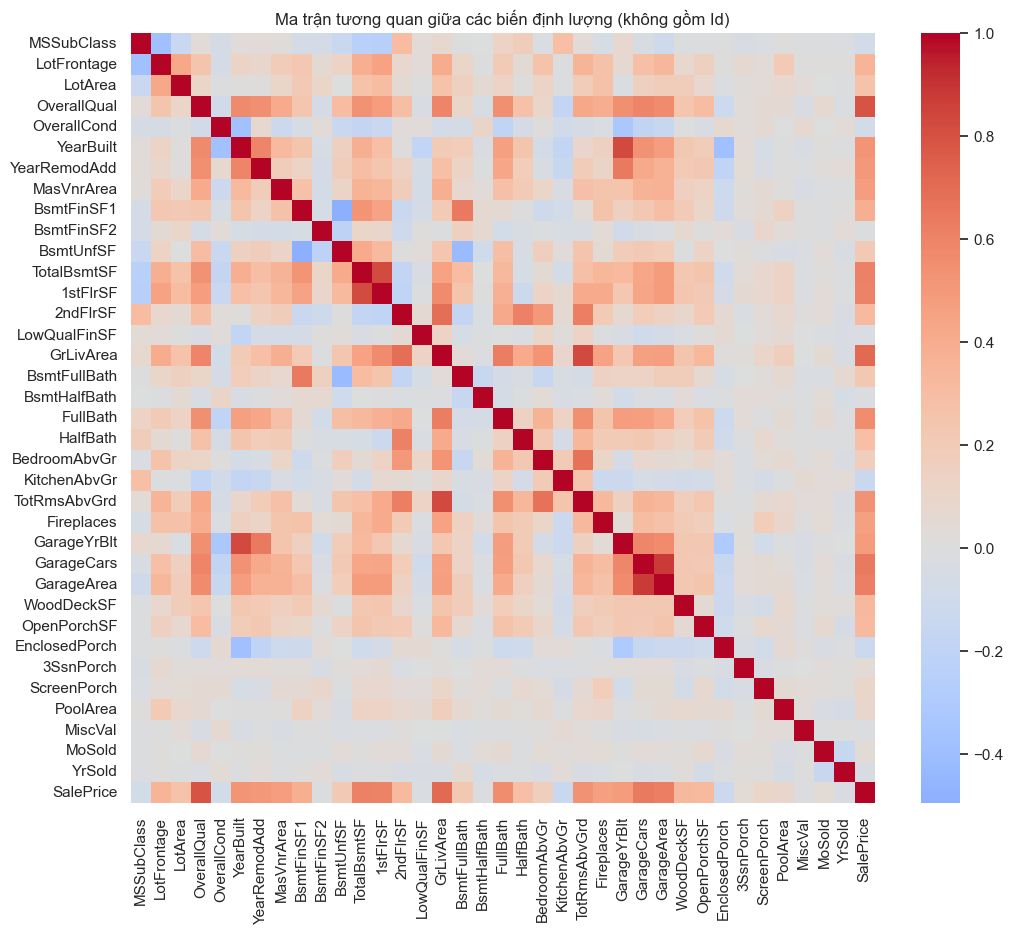

GarageCars    GarageArea      0.882475
GarageArea    GarageCars      0.882475
YearBuilt     GarageYrBlt     0.825667
GarageYrBlt   YearBuilt       0.825667
TotRmsAbvGrd  GrLivArea       0.825489
GrLivArea     TotRmsAbvGrd    0.825489
TotalBsmtSF   1stFlrSF        0.819530
1stFlrSF      TotalBsmtSF     0.819530
OverallQual   SalePrice       0.790982
SalePrice     OverallQual     0.790982
dtype: float64

In [20]:
# Loại bỏ cột Id trước khi tính tương quan
num_df = df_train.select_dtypes(include=np.number).drop(columns=['Id'])

plt.figure(figsize=(12,10))
corr_matrix = num_df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến định lượng (không gồm Id)")
plt.show()

# Hiển thị top các cặp tương quan mạnh nhất
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[(corr_pairs < 0.999) & (corr_pairs > 0.5)]
corr_pairs.head(10)


,Feature,AbsCorrelation,Correlation
0,OverallQual,0.791,0.791
1,GrLivArea,0.709,0.709
2,GarageCars,0.640,0.640
3,GarageArea,0.623,0.623
4,TotalBsmtSF,0.614,0.614
5,1stFlrSF,0.606,0.606
6,FullBath,0.561,0.561
7,TotRmsAbvGrd,0.534,0.534
8,YearBuilt,0.523,0.523
9,YearRemodAdd,0.507,0.507


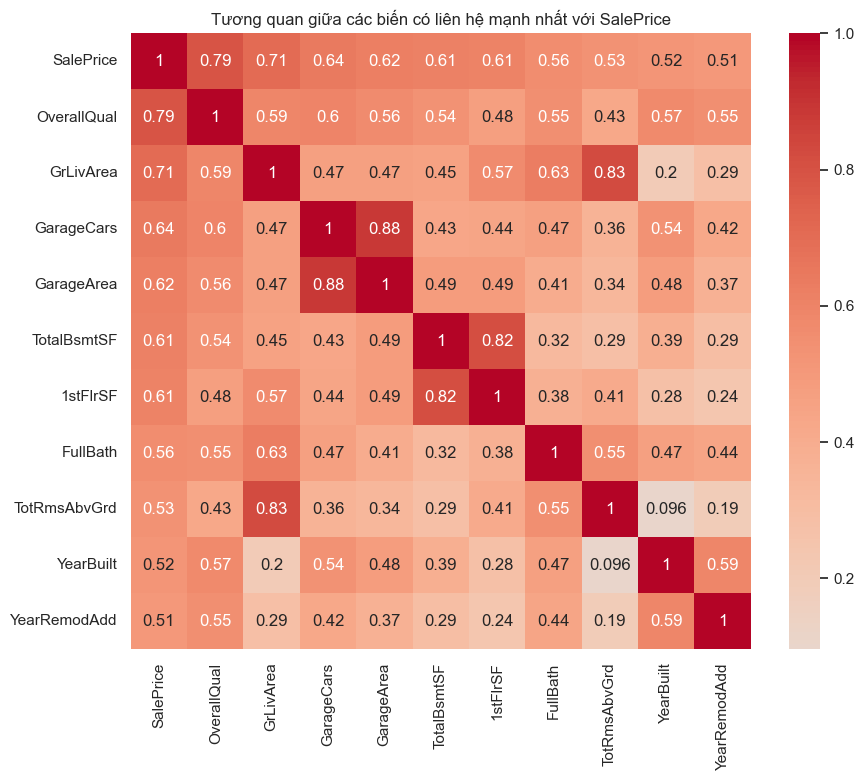

In [ ]:
corr_with_sale = corr_matrix['SalePrice'].drop(labels='SalePrice', errors='ignore')
corr_df = corr_with_sale.abs().sort_values(ascending=False).rename('AbsCorrelation').to_frame()
corr_df['Correlation'] = corr_with_sale.loc[corr_df.index].values
corr_df = corr_df.reset_index().rename(columns={'index': 'Feature'})
display(corr_df.head(10).style.format({'Correlation': '{:.3f}', 'AbsCorrelation': '{:.3f}'}).background_gradient(subset=['AbsCorrelation'], cmap='coolwarm'))

plt.figure(figsize=(10,8))
top_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11).index
sns.heatmap(num_df[top_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Tương quan giữa các biến có liên hệ mạnh nhất với SalePrice")
plt.show()


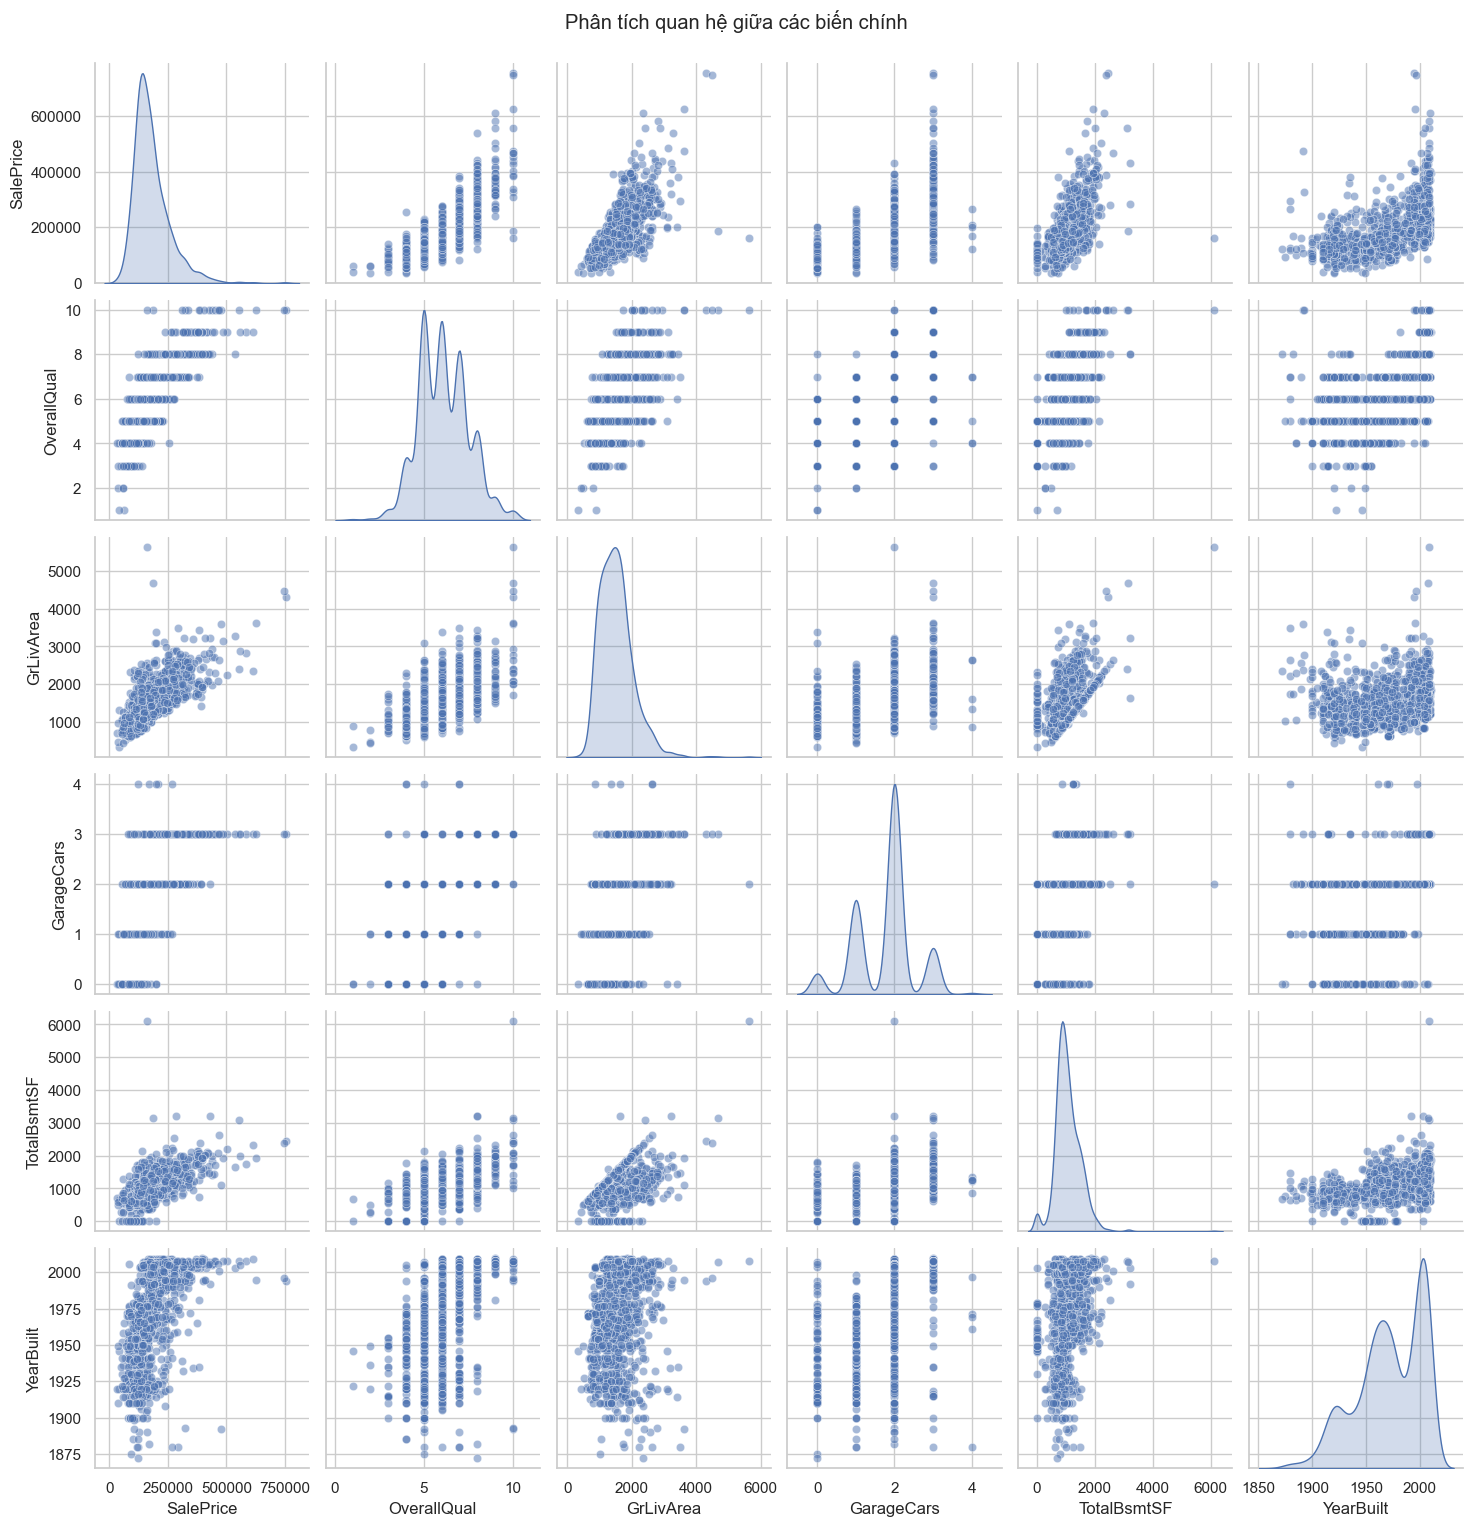

In [24]:
selected_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
sns.pairplot(num_df[selected_features], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Phân tích quan hệ giữa các biến chính", y=1.02)
plt.show()


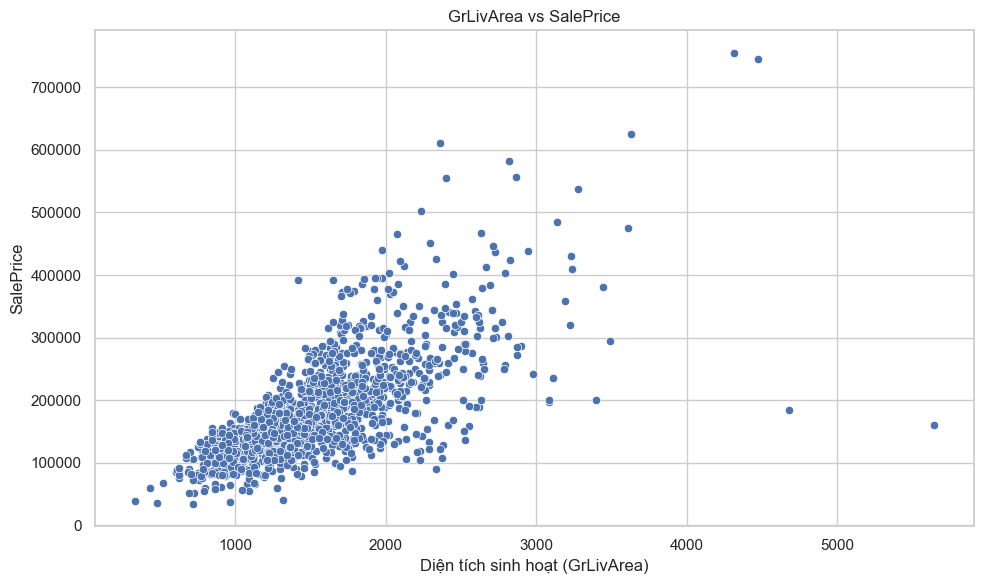

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'])
plt.title('GrLivArea vs SalePrice')
plt.xlabel('Diện tích sinh hoạt (GrLivArea)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()


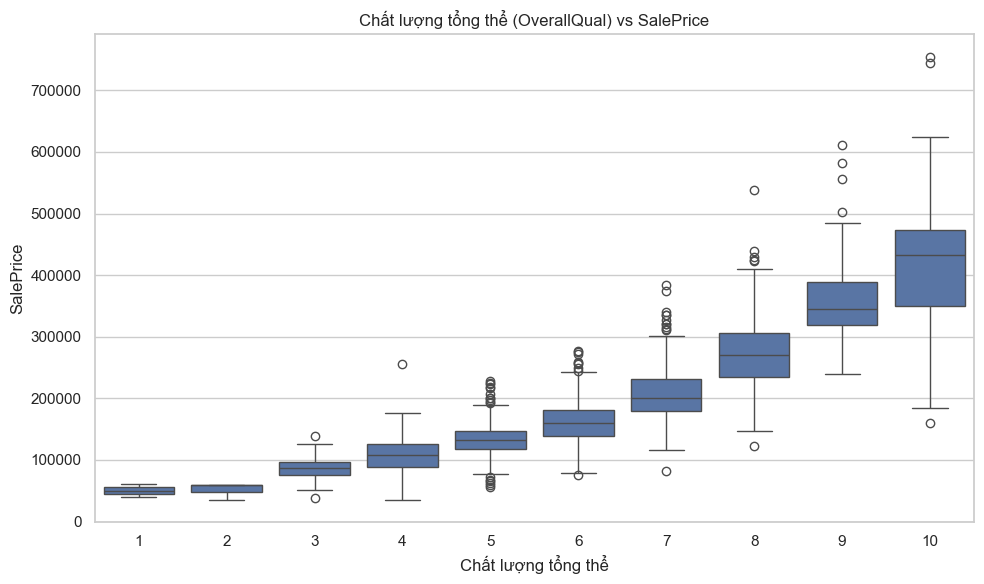

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_train['OverallQual'], y=df_train['SalePrice'])
plt.title('Chất lượng tổng thể (OverallQual) vs SalePrice')
plt.xlabel('Chất lượng tổng thể')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()


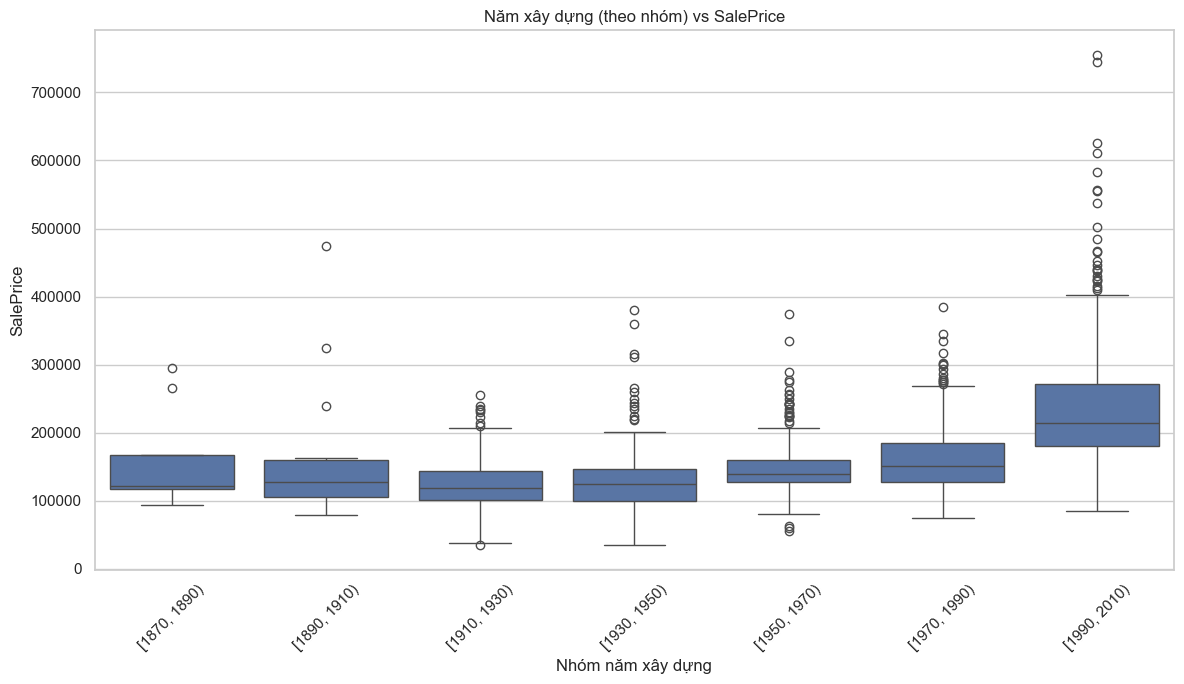

In [ ]:
df_train['YearBuilt_Group'] = pd.cut(df_train['YearBuilt'], bins=range(1870, 2030, 20), right=False)
    
plt.figure(figsize=(12, 7))
sns.boxplot(x='YearBuilt_Group', y='SalePrice', data=df_train)
plt.title('Năm xây dựng (theo nhóm) vs SalePrice')
plt.xlabel('Nhóm năm xây dựng')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
